In [163]:
import matplotlib.pyplot as plt
import os
from scipy import signal
import numpy as np
from PIL import Image

In [164]:
img = np.asarray(Image.open('./mandrill.png').convert('L'))
print(img)

[[109  53  53 ... 140 140 140]
 [109 109  53 ... 140 140 140]
 [ 53 109  53 ...  83  83  83]
 ...
 [136 136 136 ...  83  83  83]
 [136 136 136 ...  83  83  83]
 [ 21  21  21 ...  21  21  21]]


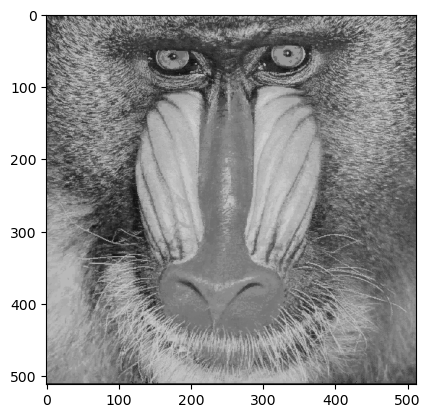

In [165]:
original = plt.imshow(img, cmap='gray', vmin=0, vmax=255)

In [166]:
def gaussian_noise(img, sigma):
    temp = np.copy(img).astype(float)
    temp += np.random.normal(0, sigma, np.shape(temp))
    return temp

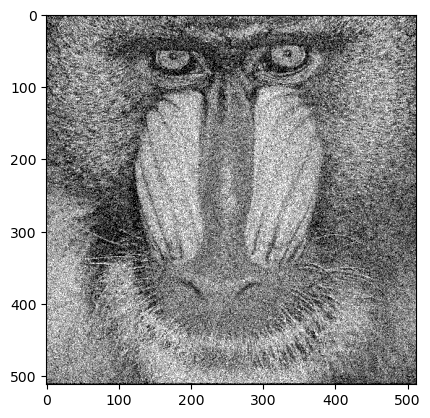

In [167]:
noisy = plt.imshow(gaussian_noise(img, 50), cmap='gray', vmin=0, vmax=255)

In [168]:
def blur(img, kernel):
    temp = np.copy(img)
    return signal.convolve(temp, kernel, "same")

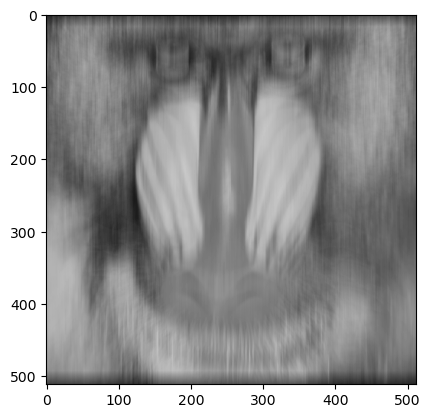

In [169]:
size = 35
v_kernel = np.zeros((size, size))
v_kernel[:, int((size - 1) / 2)] = 1 / size

blurry = plt.imshow(blur(img, v_kernel), cmap='gray', vmin=0, vmax=255)

In [170]:
def wiener_deconvolution(img, kernel, T):
    kernel_fft = np.fft.fft2(kernel, s = img.shape)
    wiener_filter = np.conj(kernel_fft) / (np.abs(kernel_fft) ** 2 + T)  
    img_fft = np.fft.fft2(img)
    return np.clip(np.fft.ifft2(img_fft * wiener_filter).real, 0, 255).astype(np.uint8)

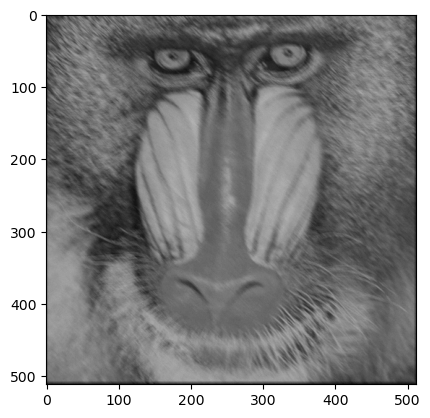

In [177]:
size = 7
v_kernel = np.zeros((size, size))
v_kernel[:, int((size - 1) / 2)] = 1 / size

diagonal_kernel = np.zeros((size, size))
for i in range(size - 1):
    diagonal_kernel[i][i] = 1/(size * 2)
    diagonal_kernel[i][i + 1] = 1/(size * 2)

observed = gaussian_noise(blur(img, diagonal_kernel), 2)
observation = plt.imshow(observed, cmap='gray', vmin=0, vmax=255)

result = wiener_deconvolution(observed, diagonal_kernel, 0.03)

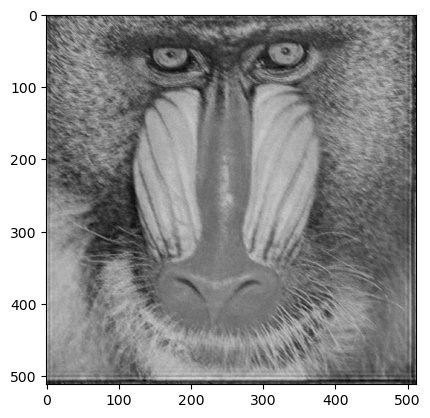

In [178]:
plt.imshow(result, cmap='gray', vmin=0, vmax=255)

In [179]:
def PrintMSE(original, restored, degraded):
    print ("Error before deconvolution: ", np.square(degraded - original).mean())
    print ("Error after deconvolution: ", np.square(restored - original).mean())

In [180]:
def MSE(original, restored, degraded):
    return np.square(restored - original).mean()

In [181]:
MSE(img, result, observed)

91.06512069702148

0.02200000000000001
Error before deconvolution:  812.3291368269864
Error after deconvolution:  90.3631706237793


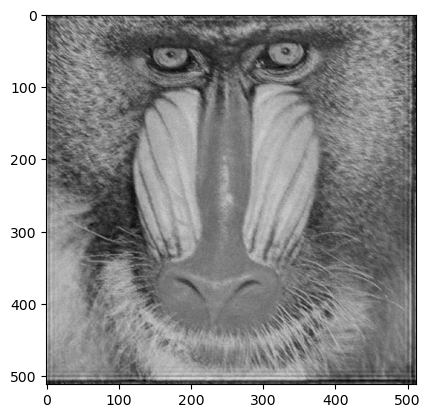

In [182]:
T = 0.01
BestMSE = 10e10
BestT = T
while T < 0.7:
    result = wiener_deconvolution(observed, diagonal_kernel, T)
    if MSE(img, result, observed) < BestMSE:
        BestMSE = MSE(img, result, observed)
        BestT = T
        BestResult = result
    T += 0.001
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=255)
print(BestT)
PrintMSE(img, BestResult, observed)